# Exploratory Data Analysis - Credit Card Fraud Detection

## Project Objective

The objective of this project is to perform exploratory data analysis on a credit card transaction dataset to understand patterns related to fraudulent activity. The analysis focuses on identifying transaction behavior, examining feature distributions, detecting outliers, and understanding relationships between variables.

Since fraudulent transactions are extremely rare in real-world financial systems, the dataset is highly imbalanced. This analysis highlights the challenges involved in fraud detection and provides insights into the characteristics of fraudulent and normal transactions.

## 1. Import Libraries

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Load Dataset

In [3]:
df = pd.read_csv("creditcard.csv")

## Dataset Description

The dataset contains credit card transactions made by European cardholders. The features V1–V28 are anonymized variables generated using Principal Component Analysis (PCA) to protect sensitive financial information.

Columns in the dataset:

- **Time** – Seconds elapsed between each transaction and the first transaction
- **V1–V28** – PCA transformed features representing anonymized transaction attributes
- **Amount** – Transaction amount
- **Class** – Target variable (0 = normal transaction, 1 = fraud)

## 3. Data Overview

In [4]:
print(df.shape)
print(df.head())
print(df.info())

(284807, 31)
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V

In [5]:
df["Class"].value_counts()
df["Class"].value_counts(normalize=True)

Class
0    0.998273
1    0.001727
Name: proportion, dtype: float64

## 4. Missing Value Analysis

In [6]:
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

### The dataset contains no missing values across all columns. This indicates that the data has already been preprocessed and cleaned. Since the dataset is complete, no imputation or row removal is required before performing exploratory analysis.

## 5. Fraud Distribution Analysis

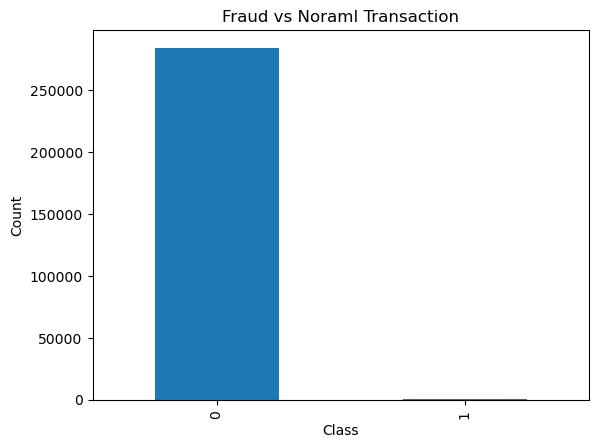

In [7]:
df["Class"].value_counts().plot(kind="bar")

plt.title("Fraud vs Noraml Transaction")
plt.xlabel("Class")
plt.ylabel("Count")

plt.show()

### From the plot
- Fraudulent transactions are extremely rare.
- The dataset is highly imbalanced
- Special evaluation metrics will be required

In [8]:
df["Amount"].describe()

count    284807.000000
mean         88.349619
std         250.120109
min           0.000000
25%           5.600000
50%          22.000000
75%          77.165000
max       25691.160000
Name: Amount, dtype: float64

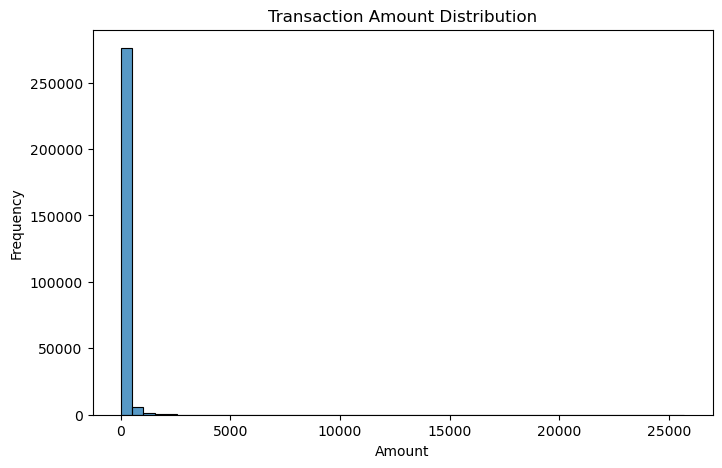

In [9]:
plt.figure(figsize=(8,5))

sns.histplot(df["Amount"], bins=50)

plt.title("Transaction Amount Distribution")
plt.xlabel("Amount")
plt.ylabel("Frequency")

plt.show()

### Most transactions in the dataset are relatively small, with an average transaction value of about 88 dollars. However, a few transactions are enormous, reaching up to $25,691. This indicates a right-skewed distribution where the majority of transactions are small while a small number have very high values.

## 6.Fraud vs Non-Fraud Analysis

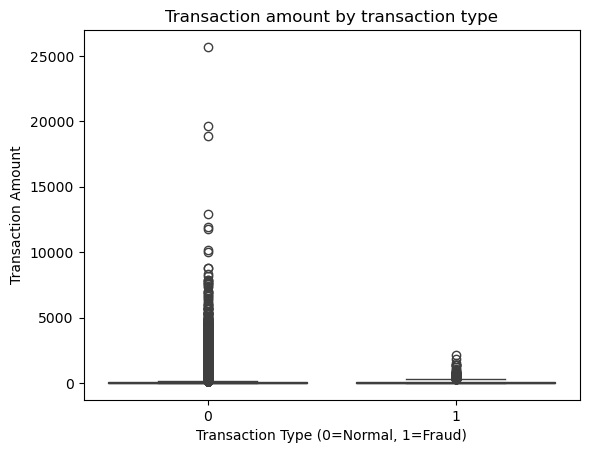

In [10]:
sns.boxplot(x="Class", y ="Amount", data=df)

plt.title("Transaction amount by transaction type")
plt.xlabel("Transaction Type (0=Normal, 1=Fraud)")
plt.ylabel("Transaction Amount")

plt.show()

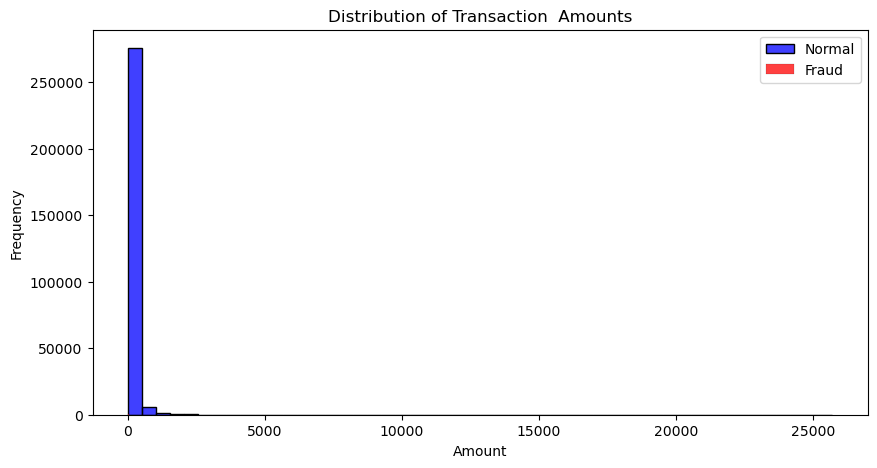

In [11]:
plt.figure(figsize=(10,5))

sns.histplot(df[df["Class"] == 0]["Amount"], bins = 50, label= "Normal", color = "blue")
sns.histplot(df[df["Class"] == 1]["Amount"], bins = 50, label= "Fraud", color = "red")

plt.legend()
plt.title("Distribution of Transaction  Amounts")
plt.xlabel("Amount")
plt.ylabel("Frequency")

plt.show()

### The distribution of transaction amounts shows that most transactions are relatively small, with a high concentration of values near zero. Only a small number of transactions involve very large amounts, producing a right-skewed distribution. Fraudulent transactions are extremely rare and therefore barely visible in the overall distribution.

## 7. Correlation Analysis

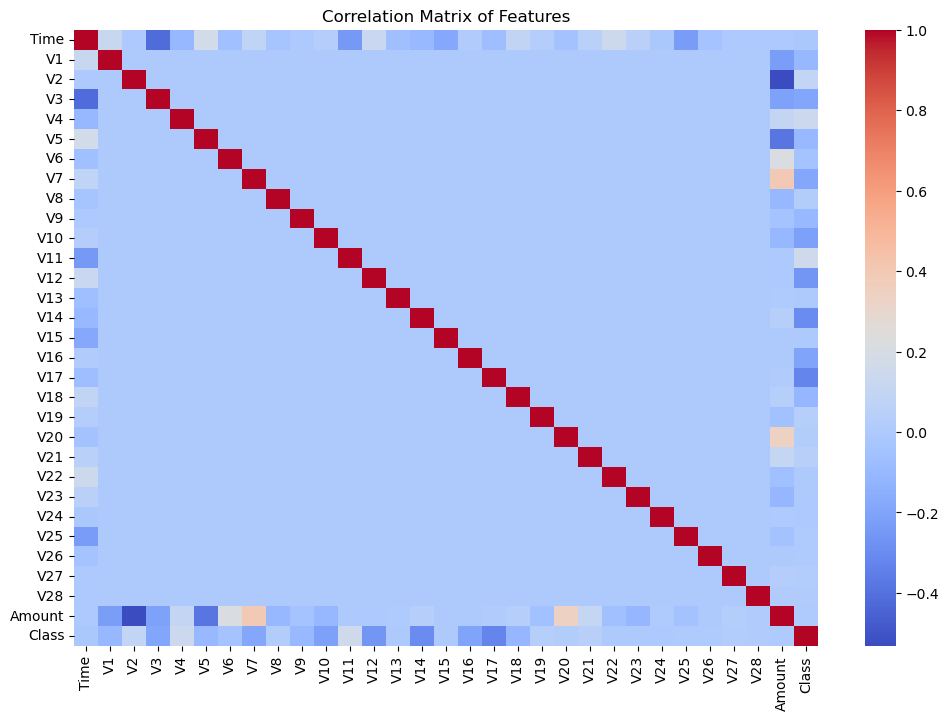

In [12]:
corr_matrix = df.corr()

plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix, cmap="coolwarm")
plt.title("Correlation Matrix of Features")
plt.show()

### The correlation heatmap shows that most features have weak correlations with each other. This is expected because the variables V1–V28 were generated using Principal Component Analysis (PCA), which produces largely uncorrelated components.

### Additionally, no single feature shows a strong correlation with the target variable (Class). This suggests that fraudulent transactions cannot be identified using a single variable and instead require patterns across multiple features.

## 8. Outliler Detection

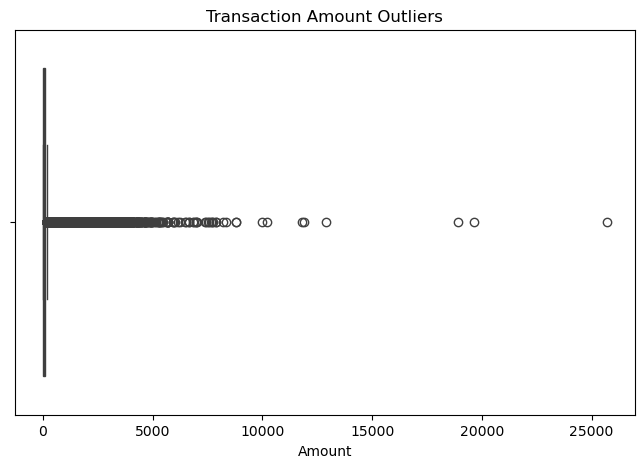

In [13]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df["Amount"])
plt.title("Transaction Amount Outliers")
plt.show()

### The boxplot for transaction amounts shows the presence of extreme outliers. Most transactions are relatively small, while only a few transactions exceed $15,000. These large values appear as outliers in the dataset and reflect the natural variation in financial transaction sizes.

## 9. Key Insights

## Key Insights

1. The dataset contains 284,807 transactions with 31 features, including 28 anonymized PCA variables.
2. Fraudulent transactions represent only about 0.17% of the dataset, creating a highly imbalanced classification problem.
3. Most transactions are small in value, with an average transaction amount of approximately 88 dollars.
4. The transaction amount distribution is strongly right-skewed, with a small number of very large transactions.
5. Correlation analysis shows weak relationships between most features due to PCA transformation.
6. No single feature strongly correlates with fraud, suggesting that fraudulent activity is identified through patterns across multiple variables.
7. Only a few transactions exceed $15,000, indicating the presence of extreme outliers in transaction amounts.